In [184]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

In [185]:
data = pd.DataFrame({'Exp':[1,2,3,4,5,6,7], 'Sal':[50000,55000,65000,80000,110000,150000,200000]})

In [186]:
data

,Exp,Sal
0,1,50000
1,2,55000
2,3,65000
3,4,80000
4,5,110000
5,6,150000
6,7,200000


In [187]:
import matplotlib.pyplot as plt

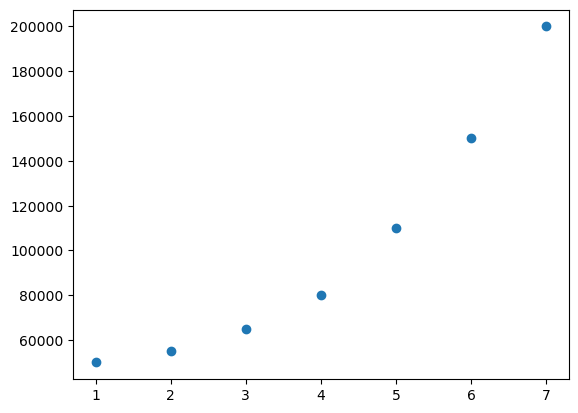

In [188]:
plt.scatter(x= data.Exp, y= data.Sal)

In [189]:
X= data[['Exp']]
y = data.Sal

In [190]:
from sklearn.linear_model import LinearRegression

In [191]:
lr = LinearRegression()

In [192]:
lr.fit(X,y)

LinearRegression()

In [193]:
y_pred = lr.predict(X)


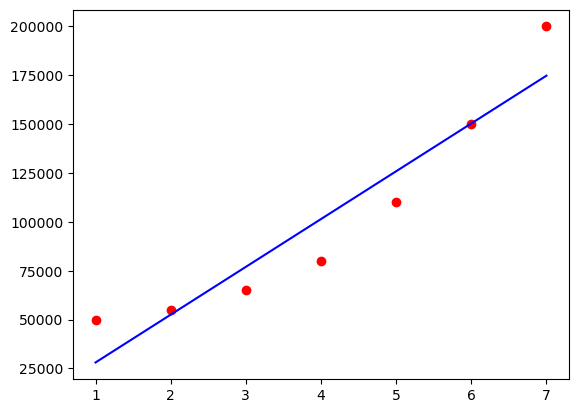

In [194]:
plt.scatter(x= data.Exp, y= data.Sal, color='red')
plt.plot(data.Exp, y_pred, color='blue')

In [196]:
from sklearn.metrics import mean_squared_error, r2_score

In [197]:
mean_squared_error(y,y_pred)

282525510.20408154

In [198]:
r2_score(y,y_pred)

0.8944433854365231

In [199]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

X_poly

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02],
       [1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03]])

In [200]:
poly.feature_names_in_

array(['Exp'], dtype=object)

In [201]:
poly.get_feature_names_out()

array(['1', 'Exp', 'Exp^2', 'Exp^3', 'Exp^4'], dtype=object)

In [202]:
pd.DataFrame(data=X_poly, columns=poly.get_feature_names_out())

,1,Exp,Exp^2,Exp^3,Exp^4
0,1.0,1.0,1.0,1.0,1.0
1,1.0,2.0,4.0,8.0,16.0
2,1.0,3.0,9.0,27.0,81.0
3,1.0,4.0,16.0,64.0,256.0
4,1.0,5.0,25.0,125.0,625.0
5,1.0,6.0,36.0,216.0,1296.0
6,1.0,7.0,49.0,343.0,2401.0


In [203]:
pr = LinearRegression()
pr.fit(X_poly, y)

LinearRegression()

In [204]:
y_pred = pr.predict(X_poly)

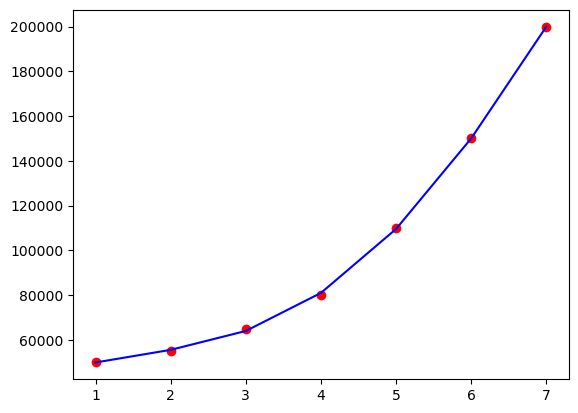

In [205]:
plt.scatter(x= data.Exp, y= data.Sal, color='red')
plt.plot(data.Exp, y_pred, color='blue')

In [206]:
r2_score(y,y_pred)

0.9998671426425906

In [207]:
data = pd.read_csv('Ice_cream selling data.csv')

In [208]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [209]:
X=data[['Temperature (°C)']]
y = data['Ice Cream Sales (units)']

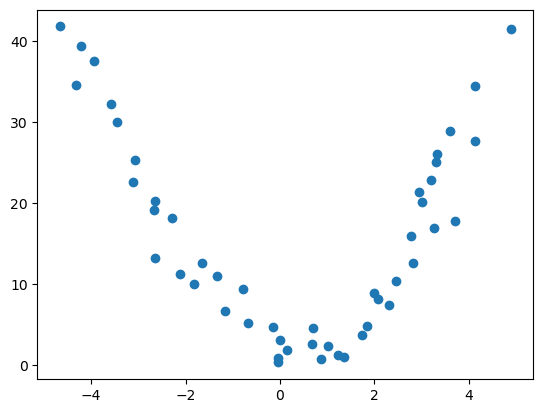

In [210]:
plt.scatter(x=X, y=y)

In [211]:
from sklearn.model_selection import train_test_split
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [212]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)

In [213]:
pr = LinearRegression()
pr.fit(X_train_poly,y_train)


LinearRegression()

In [214]:
y_pred = pr.predict(X_train_poly)

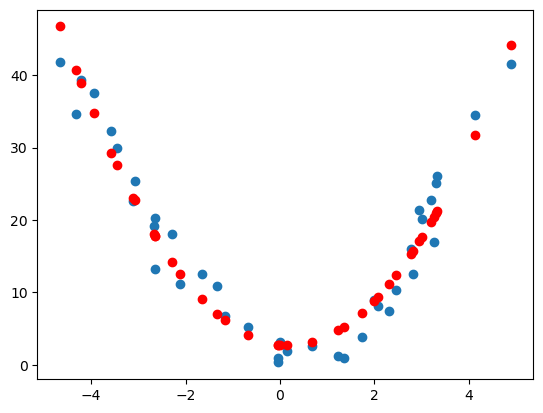

In [218]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(X_train,y_pred, color='red')

In [219]:
X_test_poly = poly.transform(X_test)

In [220]:
y_pred  = pr.predict(X_test_poly)

In [221]:
r2_score(y_test,y_pred)


0.8430551371938841